/tmp/ipykernel_169703/2660256397.py:69: UserWarning: The handle <matplotlib.patches.Rectangle object at 0x14a81c7e2340> has a label of '_nolegend_' which cannot be automatically added to the legend.
  ax1.legend(bars_combined, labels_combined, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
/tmp/ipykernel_169703/2660256397.py:69: UserWarning: The handle <matplotlib.patches.Rectangle object at 0x14a81c7ff550> has a label of '_nolegend_' which cannot be automatically added to the legend.
  ax1.legend(bars_combined, labels_combined, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
/tmp/ipykernel_169703/2660256397.py:69: UserWarning: The handle <matplotlib.patches.Rectangle object at 0x14a81c7e26a0> has a label of '_nolegend_' which cannot be automatically added to the legend.
  ax1.legend(bars_combined, labels_combined, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
/tmp/ipykernel_169703/2660256397.py:69: UserWarning: The handle 

✅ Figure saved as 'bindingnet_results.png' (high resolution)


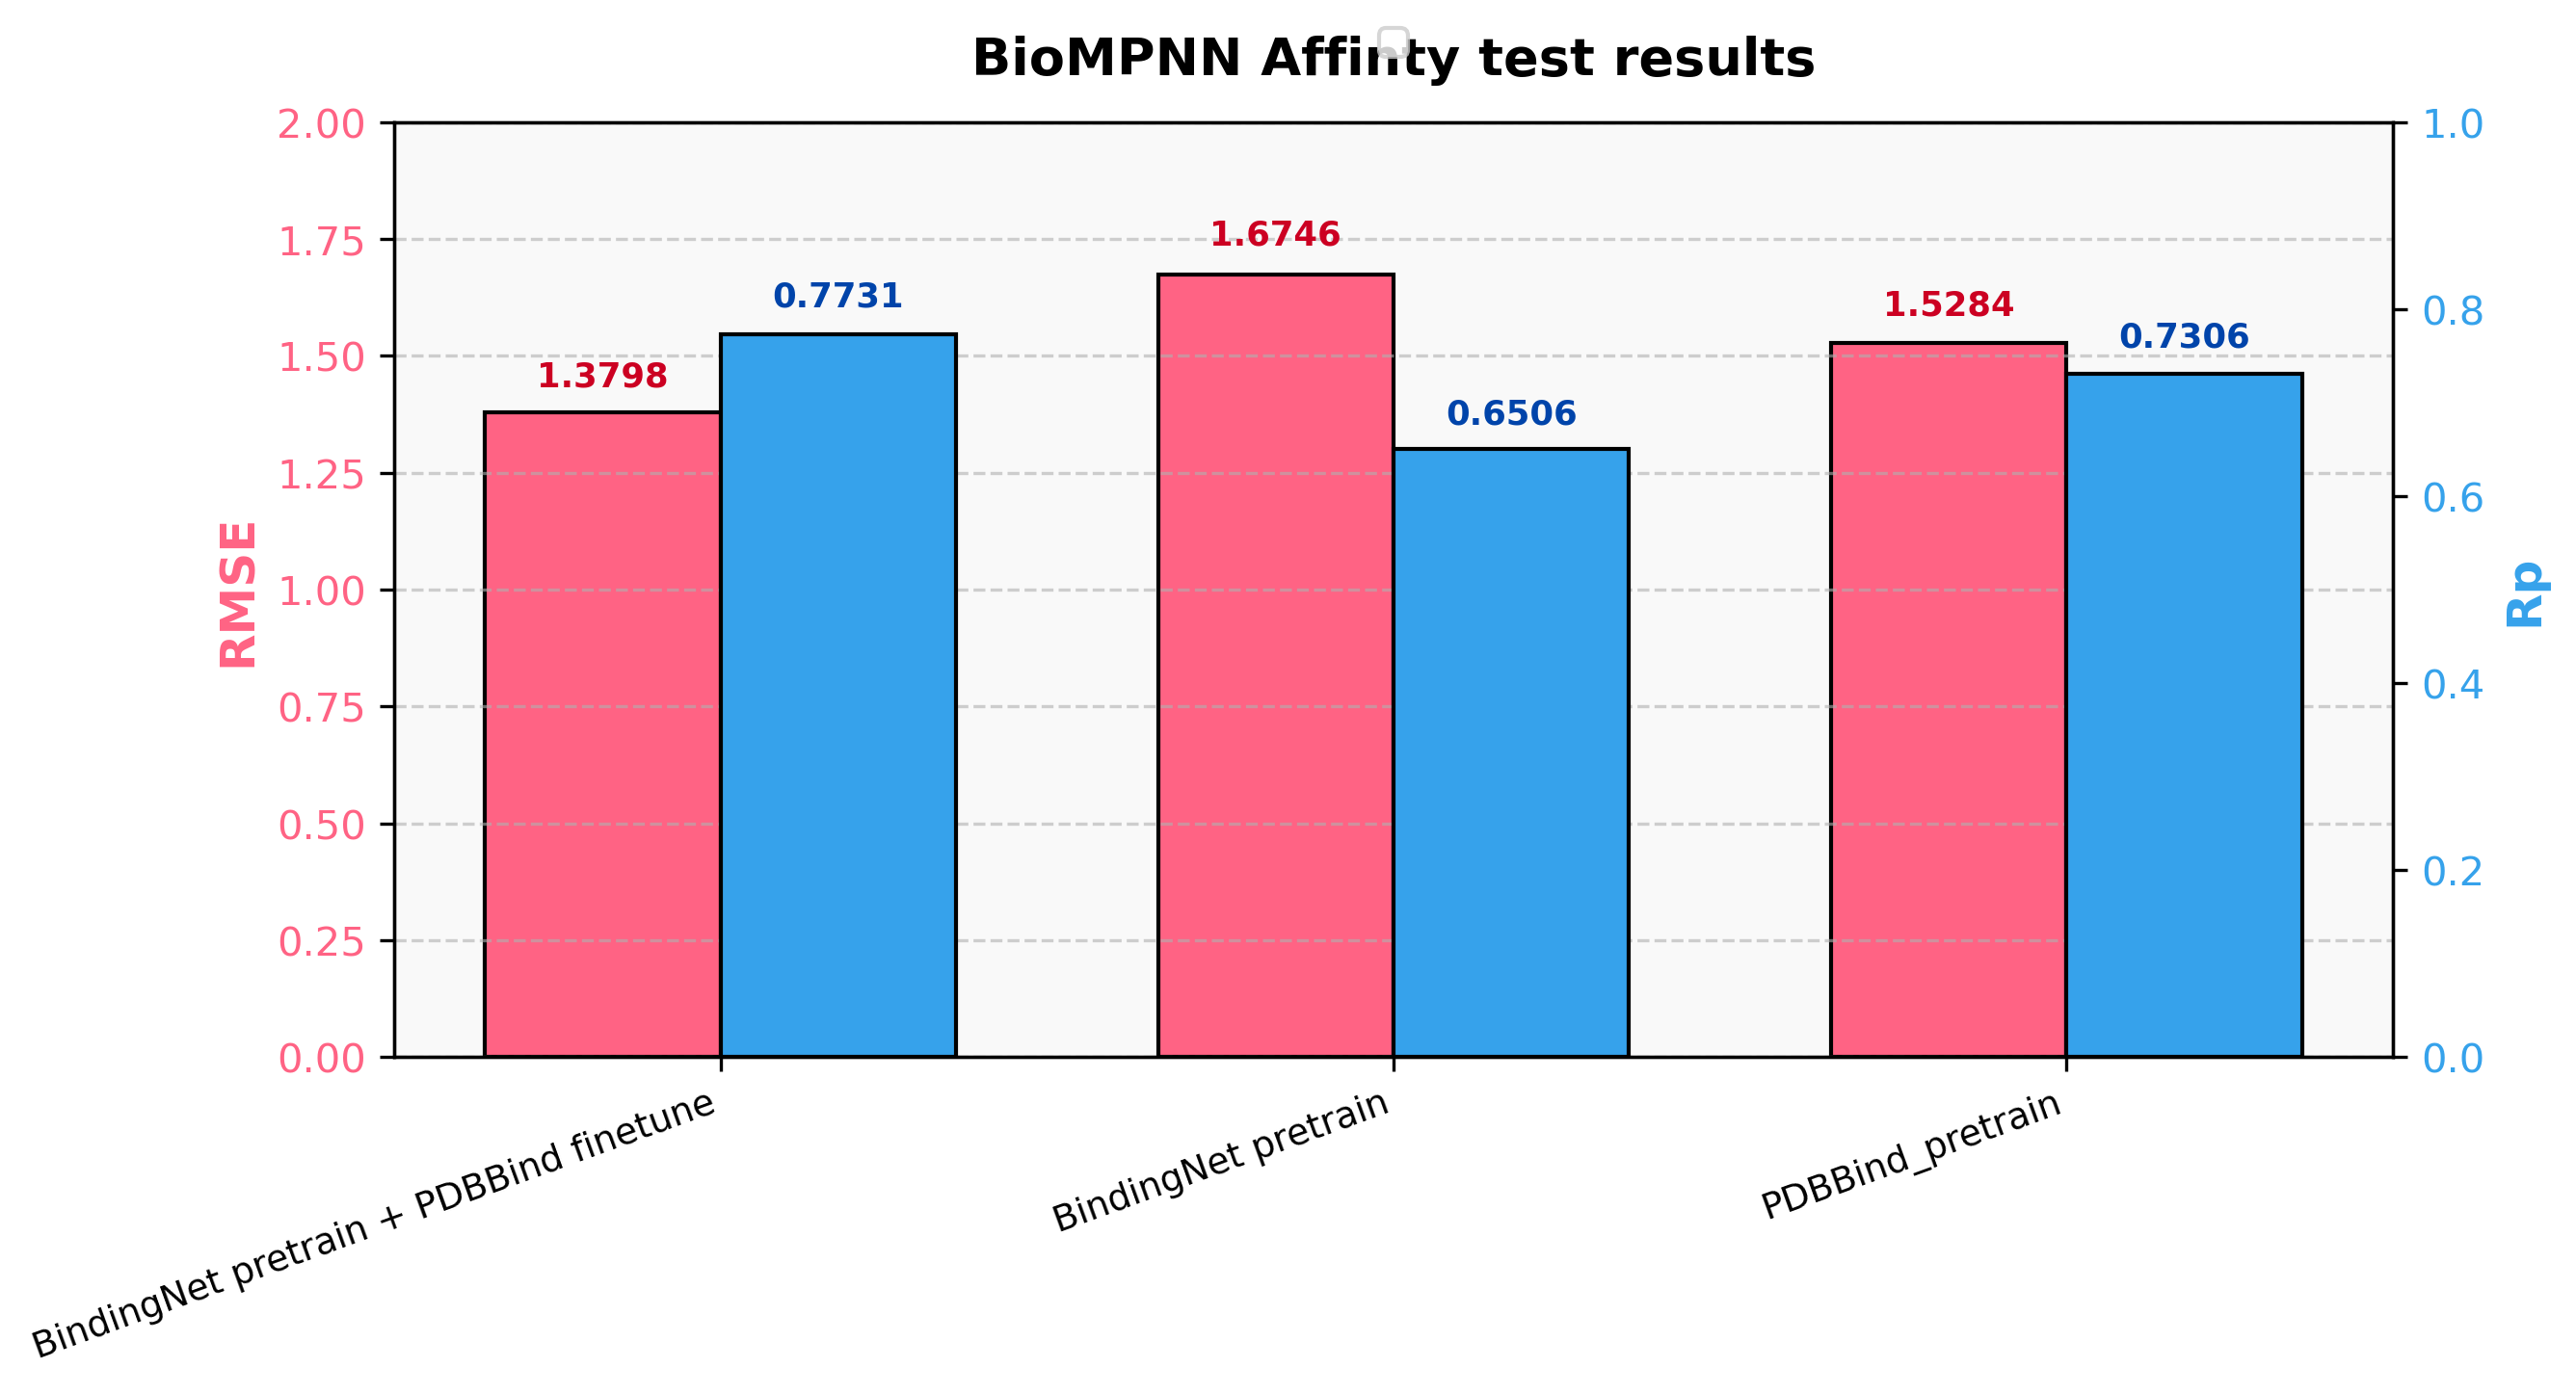

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Data ====
models = [
    "BindingNet pretrain + PDBBind finetune",
    "BindingNet pretrain",
    "PDBBind_pretrain"
]

rmse = [1.3798, 1.6746, 1.5284]
rp = [0.7731, 0.6506, 0.7306]

# ==== Plot settings ====
x = np.arange(len(models))
width = 0.35
plt.style.use('default')

fig, ax1 = plt.subplots(figsize=(9, 5), dpi=300)  # 高 DPI 提升清晰度
fig.patch.set_facecolor('white')
ax1.set_facecolor('#f9f9f9')

# ==== Left axis (RMSE) ====
bars_rmse = ax1.bar(
    x - width/2, rmse, width,
    label='RMSE ↓ (lower is better)',
    color='#ff6384', edgecolor='black'
)
ax1.set_ylabel("RMSE", color='#ff6384', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#ff6384')
ax1.set_ylim(0, 2)

# ==== Right axis (Rp) ====
ax2 = ax1.twinx()
bars_rp = ax2.bar(
    x + width/2, rp, width,
    label='Rp ↑ (higher is better)',
    color='#36a2eb', edgecolor='black'
)
ax2.set_ylabel("Rp", color='#36a2eb', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#36a2eb')
ax2.set_ylim(0, 1)

# ==== Add value labels ====
def add_labels(ax, bars, color):
    """Add numeric labels on top of bars."""
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (0.03 * height),
            f"{height:.4f}",
            ha='center', va='bottom',
            fontsize=8.5, color=color, fontweight='bold'
        )

add_labels(ax1, bars_rmse, '#cc0022')
add_labels(ax2, bars_rp, '#0044aa')

# ==== X-axis settings ====
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
ax1.set_title("BioMPNN Affinty test results", fontsize=13, fontweight='bold', pad=12)

# ==== Legends ====
# Combine both legends
bars_combined = bars_rmse + bars_rp
labels_combined = [b.get_label() for b in bars_combined]
ax1.legend(bars_combined, labels_combined, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)

# ==== Layout and grid ====
ax1.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# ==== Save high-res image ====
plt.savefig("BioMPNN_Affinty_results.png", dpi=300, bbox_inches='tight')
print("✅ Figure saved as 'bindingnet_results.png' (high resolution)")

plt.show()